In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Работа со skills

Анализ навыков для сайта [hirify](https://hirify.me).

In [100]:
data = pd.read_csv('vacancies_cleaned.csv')
data.sample(3)

,title,link,tags,company,skills,salary,relocation,employment_type,onsite,remote,hybrid,lead,c_level,senior,director,trainee,head,middle,junior,location
5998,Junior/Middle QA Engineer (Gamedev),https://hirify.me/jobs/434581-juniormiddle-qa-...,"['remote (Global)/onsite', 'Russia', 'fulltime...",Matryoshka,"['gamedev', 'jira', 'mobile testing', 'test do...",NaN,False,fulltime,True,False,True,False,False,False,False,False,False,True,True,Russia
6724,Ведущий менеджер по подбору персонала,https://hirify.me/jobs/433770-vedushhii-menedz...,"['onsite', 'Russia', 'fulltime', 'lead']",ИРВИН 2,"['hr', 'recruiting', 'talent acquisition', 'e ...",NaN,False,fulltime,False,True,True,True,False,False,False,False,False,False,False,Russia
1623,Affiliate Team Lead (Igaming),https://hirify.me/jobs/411803-affiliate-team-l...,"['remote (Global)', 'fulltime', 'lead']",NaN,"['igaming', 'affiliate marketing', 'cpa', 'tra...",NaN,False,fulltime,True,False,True,True,False,False,False,False,False,False,False,NaN


Данные в колонке представлены строковым типом. для дальнейшей обработки преобразуем в массив с помощью функции: 

In [101]:
def str_to_list(skills_string):

    try:
        if not skills_string or skills_string == "[]":
            return []
        skills_string = skills_string[1:-1].split(",")
        skills_list = [
            skill.replace("'", "").strip().lower() for skill in skills_string
        ]
        skills_list = set(skills_list)
        return list(skills_list)

    except Exception:
        return []

In [102]:
data["skills"] = data["skills"].apply(lambda x: str_to_list(x))

Перед началом обработки определим дополнительный признак - количество требований вакансии.

Так в массивах навыков содержаться признаки вида `+x skills`, для определения корректного количества признаков используется функция: 

In [103]:
def get_correct_len(array):
    l = 0
    if array is None:
        return 0
    for value in array:
        if ' skills' in value and value[0] == '+':
            l += int(value.split(' ')[0])
        else:
            l += 1
    return l

Оценим, как распределено количество требуемых инструментов для различных вакансий.

In [104]:
data['skills_num'] = data["skills"].apply(lambda x: get_correct_len(x))
skills_length_grouped = data["skills_num"].value_counts()
skills_length_grouped

skills_num
8     2241
7     2167
9     1639
6     1381
10    1017
5      725
11     328
4      323
3      170
12     136
2       82
13      72
14      68
1       53
15      39
16      31
17      24
18      13
22      10
19       9
20       9
21       4
24       3
28       2
0        1
30       1
32       1
34       1
27       1
26       1
25       1
Name: count, dtype: int64

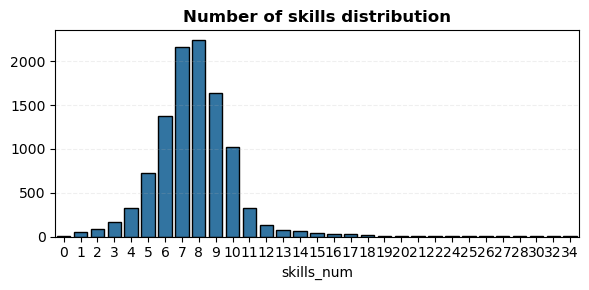

In [105]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(
    x=skills_length_grouped.index,
    y=skills_length_grouped.values,
    edgecolor="black",
)
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_title("Number of skills distribution", fontweight="bold")
plt.tight_layout()

Большинство вакансий требуют от 5 до 10 навыков. При этом наблюдается сильный правый хвост распределения числа признаков.

Попробуем определить, какое среднее количество скиллов нужно каждому из грейдов: 

In [114]:
data.columns

Index(['title', 'link', 'tags', 'company', 'skills', 'salary', 'relocation',
       'employment_type', 'onsite', 'remote', 'hybrid', 'lead', 'c_level',
       'senior', 'director', 'trainee', 'head', 'middle', 'junior', 'location',
       'skills_num'],
      dtype='object')

In [123]:
grades = ['lead', 'senior', 'director', 'head', 'middle', 'junior', 'trainee']
grades_avg = []
for grade in grades: 
    grades_avg.append(data[data[grade]]['skills_num'].mean())
level_groupped = pd.Series(grades_avg, grades).sort_values()
level_groupped

trainee     6.697842
junior      7.028169
head        7.310204
director    7.641553
middle      7.845096
lead        8.230565
senior      8.333882
dtype: float64

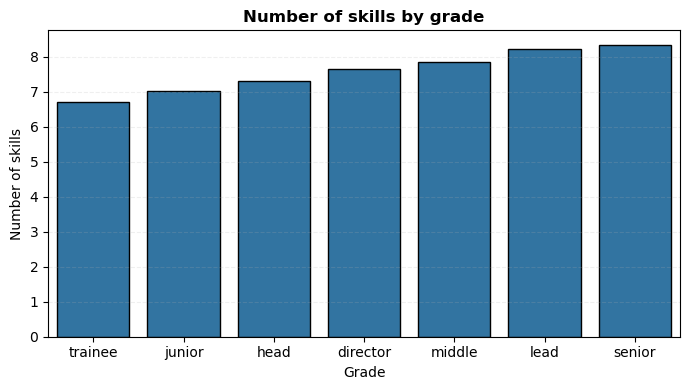

In [124]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=level_groupped,
    edgecolor="black"
)

ax.set_xlabel("Grade")
ax.set_ylabel("Number of skills")
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_title("Number of skills by grade", fontweight="bold")
plt.tight_layout()

Для формирования дополнительного столбца используется метод [`explode`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html):

In [106]:
data_skills = (
    data.reset_index()[["index", "skills"]].explode("skills").rename(columns={"skills": "skill", "index": 'id'})
)
data_skills

,id,skill
0,0,sales
0,0,healthcare
0,0,saas
0,0,negotiation
0,0,crm
...,...,...
10552,10552,sql
10552,10552,customer support
10552,10552,databases
10552,10552,excel


In [107]:
data_skills['skill'].value_counts().head(10)

skill
ai           3190
+3 skills    2241
+2 skills    2167
python       1718
+4 skills    1639
+1 skills    1381
+5 skills    1017
sql           979
saas          920
fintech       880
Name: count, dtype: int64

In [108]:
print(f'Количество пропусков: {data_skills['skill'].isna().sum()}')

Количество пропусков: 1


In [109]:
data_skills = data_skills.dropna()

In [110]:
data_skills[data_skills['skill'].str.contains(r"\+")] = "No "

C:\Users\Anton\AppData\Local\Temp\ipykernel_33224\4215119377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_skills[data_skills['skill'].str.contains(r"\+")] = "No "
C:\Users\Anton\AppData\Local\Temp\ipykernel_33224\4215119377.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No ' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_skills[data_skills['skill'].str.contains(r"\+")] = "No "
